# TopoVein — Preprocessing & Skeletonization Exploration (UTFVP Dataset)

**Branch:** `Samiksha`  
**Purpose:** Explore and validate preprocessing steps on the UTwente UTFVP dataset before formalizing code modules.  
**Dataset:** `Published_database_UTFVP/`  


# Cell 1 — Imports & Custom Anisotropic Diffusion Engine

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from pathlib import Path

# Display images larger in notebook
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['image.cmap'] = 'gray'

# ── Anisotropic diffusion — Perona-Malik implementation ──────
def anisotropic_diffusion(img, num_iter=15, kappa=30.0, gamma=0.15, option=1):
    """
    Perona-Malik anisotropic diffusion filter for boundary conservation.
    option 1 → exponential edge-stopping  (highly stable for vascular boundaries)
    option 2 → rational edge-stopping     (sharper high-contrast variations)
    """
    img_float = img.astype(np.float32)

    for _ in range(num_iter):
        # Calculate localized directional spatial differences
        delta_N = np.roll(img_float, -1, axis=0) - img_float
        delta_S = np.roll(img_float,  1, axis=0) - img_float
        delta_E = np.roll(img_float,  1, axis=1) - img_float
        delta_W = np.roll(img_float, -1, axis=1) - img_float

        # Evaluate localized diffusion coefficients
        if option == 1:
            c_N = np.exp(-(delta_N / kappa) ** 2)
            c_S = np.exp(-(delta_S / kappa) ** 2)
            c_E = np.exp(-(delta_E / kappa) ** 2)
            c_W = np.exp(-(delta_W / kappa) ** 2)
        else:
            c_N = 1.0 / (1.0 + (delta_N / kappa) ** 2)
            c_S = 1.0 / (1.0 + (delta_S / kappa) ** 2)
            c_E = 1.0 / (1.0 + (delta_E / kappa) ** 2)
            c_W = 1.0 / (1.0 + (delta_W / kappa) ** 2)

        # Apply localized update mapping
        img_float += gamma * (c_N * delta_N + c_S * delta_S + c_E * delta_E + c_W * delta_W)
        np.clip(img_float, 0.0, 255.0, out=img_float)

    return img_float.astype(np.uint8)

print("✓ All imports and custom Anisotropic Diffusion engine loaded successfully.")

✓ All imports and custom Anisotropic Diffusion engine loaded successfully.


# Cell 2 — Dataset path setup (UTFVP Variant)

In [2]:
# Absolute path definition of newly unzipped UTwente repository target
DATASET_ROOT = Path(r"E:\topovein-iampro\20151211-utwente-vingervein")

# UTFVP typically groups images directly or inside an interior sub-folder layer
print('Dataset root target exists:', DATASET_ROOT.exists())

# Gather all .png file arrays inside the folder layer to inspect tracking state
if DATASET_ROOT.exists():
    all_images = sorted(list(DATASET_ROOT.glob("**/*.png")))
    print(f'Total vascular subset frames found: {len(all_images)}')
    print('\nFirst 5 data file entities identified:')
    for img_p in all_images[:5]:
        print(' ', img_p.name)
else:
    print('❌ [ERROR] Verify your absolute file track mapping constraints.')

Dataset root target exists: True
Total vascular subset frames found: 1440

First 5 data file entities identified:
  0001_1_1_120509-135315.png
  0001_1_2_120509-135537.png
  0001_1_3_120523-100701.png
  0001_1_4_120523-100916.png
  0001_2_1_120509-135338.png


# Cell 3 — Load and visualize one raw UTFVP image

Target Image identity name: 0001_1_1_120509-135315.png
Image base shape layout: (380, 672, 3)
Image base matrix dtype: uint8
Channels structured identically: True


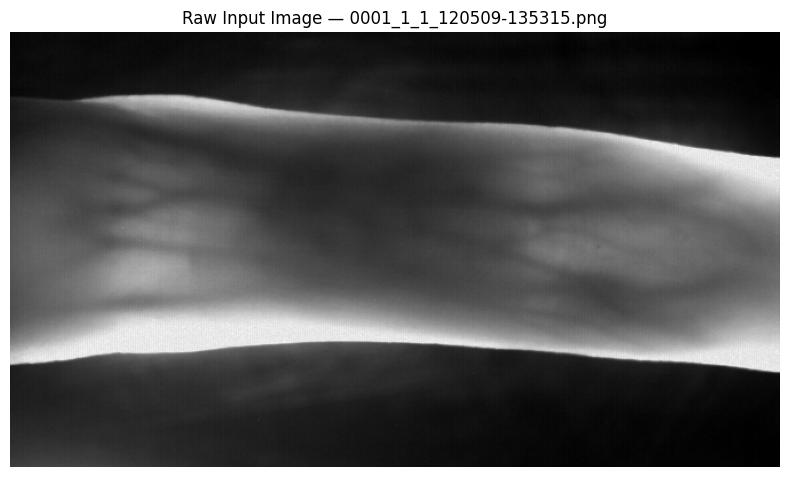

In [3]:
# Select the first sample frame out of the collected list directory
sample_target_path = all_images[0]
img_raw = cv2.imread(str(sample_target_path))

print('Target Image identity name:', sample_target_path.name)
print('Image base shape layout:', img_raw.shape)
print('Image base matrix dtype:', img_raw.dtype)

# Standard evaluation validation check
if len(img_raw.shape) == 3:
    b, g, r = cv2.split(img_raw)
    print('Channels structured identically:', np.array_equal(b, g) and np.array_equal(g, r))

# Base plot presentation rendering
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
plt.title(f'Raw Input Image — {sample_target_path.name}')
plt.axis('off')
plt.tight_layout()
plt.show()

# Cell 4 — Convert to grayscale

Grayscale matrix shape bounds: (380, 672)
Calculated mean baseline weight: 69.41


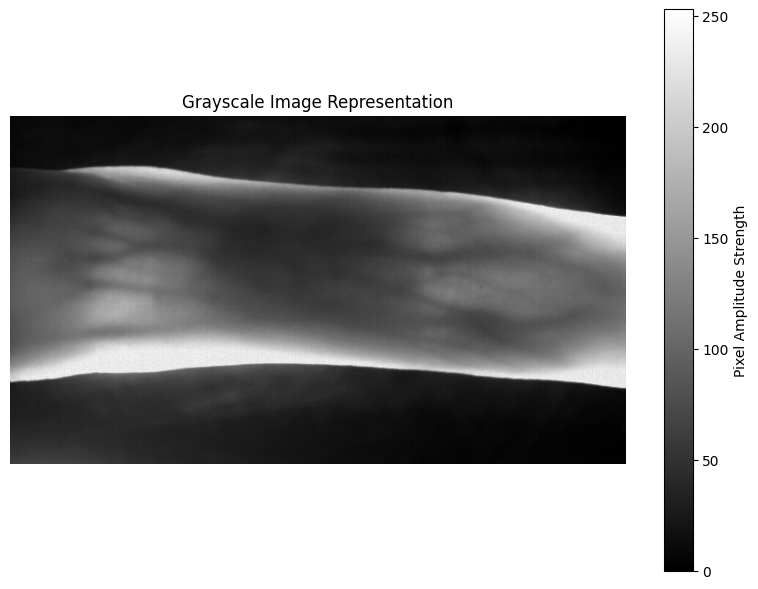

In [4]:
# Strip unnecessary data configurations by flattening channels
img_gray = cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY)
print('Grayscale matrix shape bounds:', img_gray.shape)
print('Calculated mean baseline weight:', img_gray.mean().round(2))

plt.figure(figsize=(8, 6))
plt.imshow(img_gray)
plt.title('Grayscale Image Representation')
plt.colorbar(label='Pixel Amplitude Strength')
plt.axis('off')
plt.tight_layout()
plt.show()

# Cell 5 — CLAHE enhancement (test different clipLimit values)

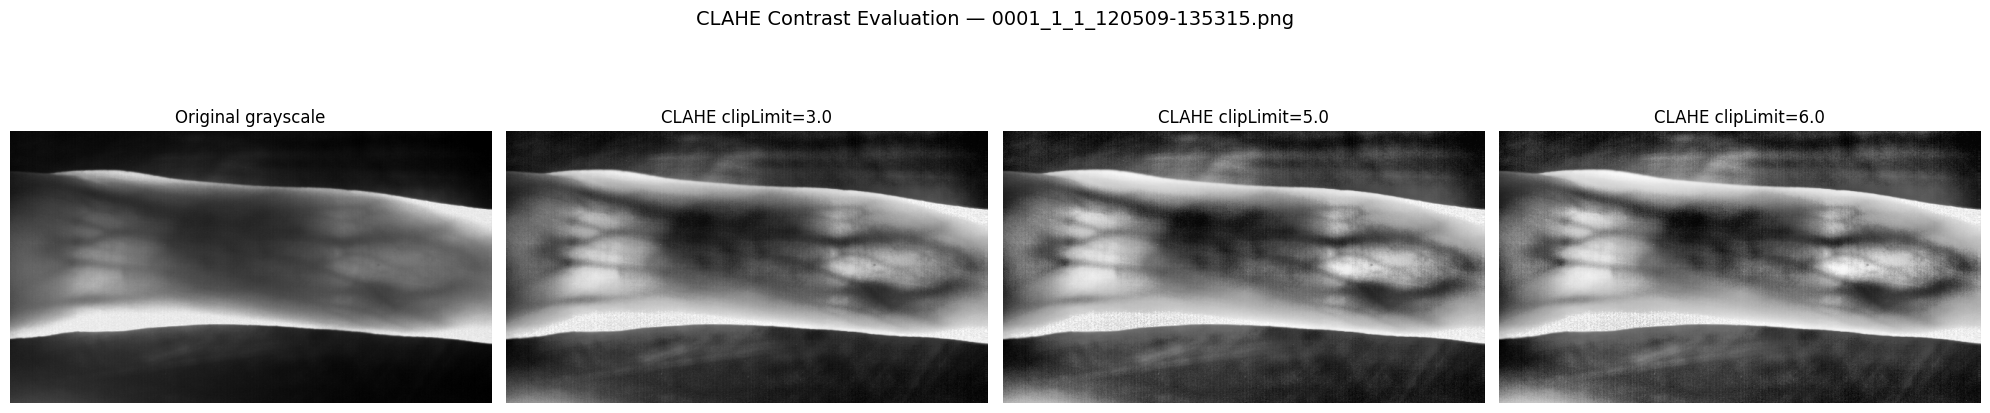

In [5]:
# Parameter limit variants to evaluate vascular illumination balance
clip_limits = [3.0, 5.0, 6.0]
tile_grid = (5, 5)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_gray)
axes[0].set_title('Original grayscale')
axes[0].axis('off')

clahe_results = {}
for i, clip in enumerate(clip_limits):
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile_grid)
    enhanced = clahe.apply(img_gray)
    clahe_results[clip] = enhanced
    axes[i+1].imshow(enhanced)
    axes[i+1].set_title(f'CLAHE clipLimit={clip}')
    axes[i+1].axis('off')

plt.suptitle(f'CLAHE Contrast Evaluation — {sample_target_path.name}', fontsize=14)
plt.tight_layout()
plt.show()

# Cell 6 — Anisotropic diffusion (edge-preserving smoothing)

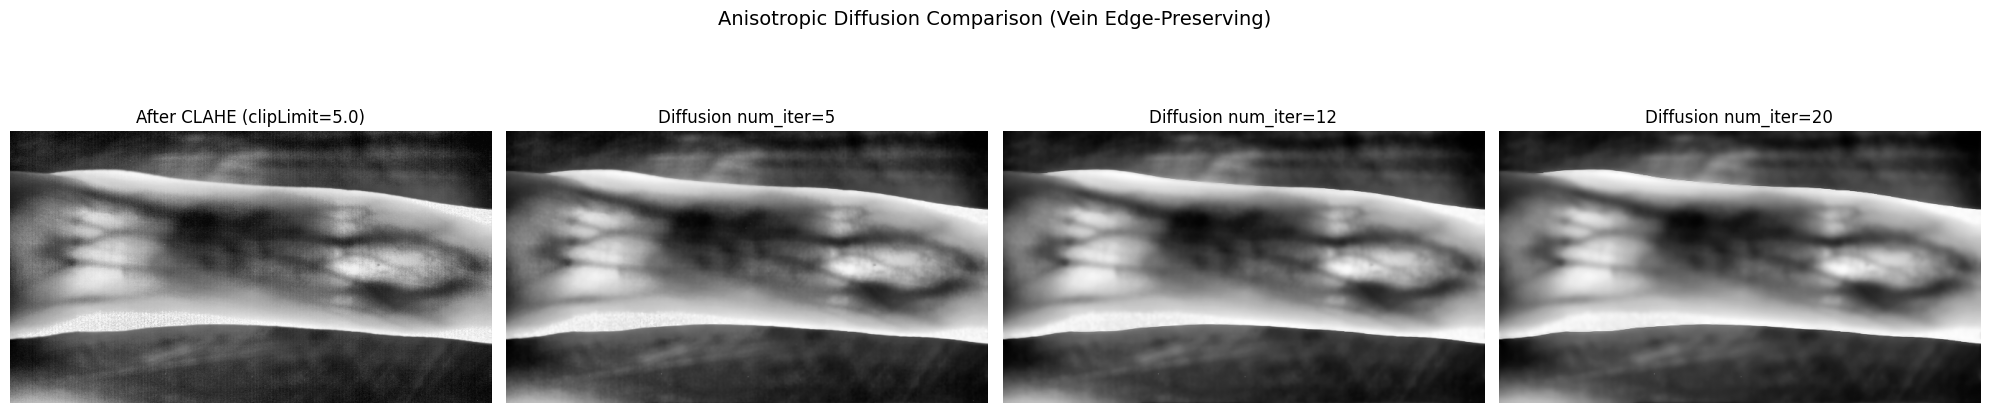

In [6]:
# Pass through optimized CLAHE contrast tracking maps
img_clahe = clahe_results[5.0]

# Evaluate various diffusion iteration numbers (higher values mean more interior flattening)
iterations = [5, 12, 20]
kappa_param = 30.0   # Boundary threshold parameter limits
gamma_step = 0.15    # Numeric updates process speed

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_clahe)
axes[0].set_title('After CLAHE (clipLimit=5.0)')
axes[0].axis('off')

diffusion_results = {}
for i, n_iter in enumerate(iterations):
    # Process the image with the custom Perona-Malik execution array
    smoothed = anisotropic_diffusion(img_clahe, num_iter=n_iter, kappa=kappa_param, gamma=gamma_step, option=1)
    diffusion_results[n_iter] = smoothed
    
    axes[i+1].imshow(smoothed)
    axes[i+1].set_title(f'Diffusion num_iter={n_iter}')
    axes[i+1].axis('off')

plt.suptitle('Anisotropic Diffusion Comparison (Vein Edge-Preserving)', fontsize=14)
plt.tight_layout()
plt.show()

# Cell 7 — Otsu binarization

Otsu threshold computed automatically: 121.0


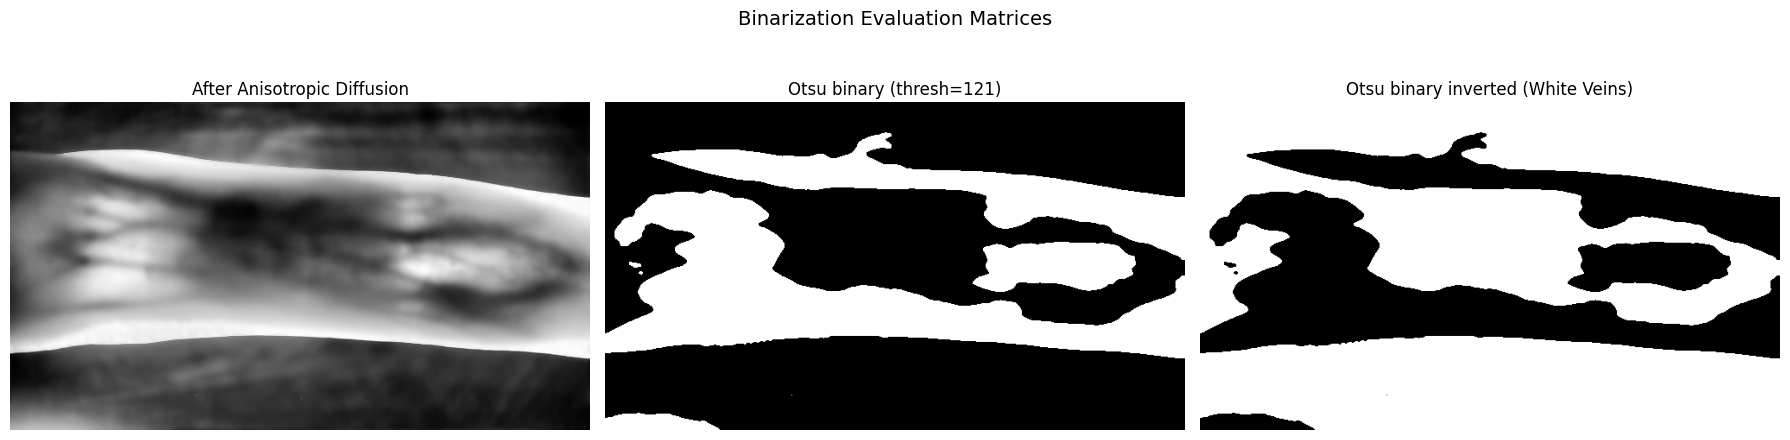

In [7]:
# Isolate smooth maps using iteration evaluation target parameters
img_smoothed = diffusion_results[20]

# Auto-evaluate threshold target constraints using Otsu processing parameters
otsu_thresh, img_binary = cv2.threshold(
    img_smoothed, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print(f'Otsu threshold computed automatically: {otsu_thresh}')

# Invert processing sequence map fields so that blood vessels map to white features (255)
_, img_binary_inv = cv2.threshold(
    img_smoothed, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img_smoothed)
axes[0].set_title('After Anisotropic Diffusion')
axes[0].axis('off')

axes[1].imshow(img_binary)
axes[1].set_title(f'Otsu binary (thresh={int(otsu_thresh)})')
axes[1].axis('off')

axes[2].imshow(img_binary_inv)
axes[2].set_title('Otsu binary inverted (White Veins)')
axes[2].axis('off')

plt.suptitle('Binarization Evaluation Matrices', fontsize=14)
plt.tight_layout()
plt.show()

# Cell 8 — Skeletonization

In [8]:
# Map boolean tracking configurations over white structural targets
skeleton = skeletonize(img_binary_inv > 0)

print('Vascular structural topology thinning sequence completed.')
print('Total registered singular coordinate tracking elements:', np.sum(skeleton))

Vascular structural topology thinning sequence completed.
Total registered singular coordinate tracking elements: 3000


# Cell 9 — Overlay skeleton on original image

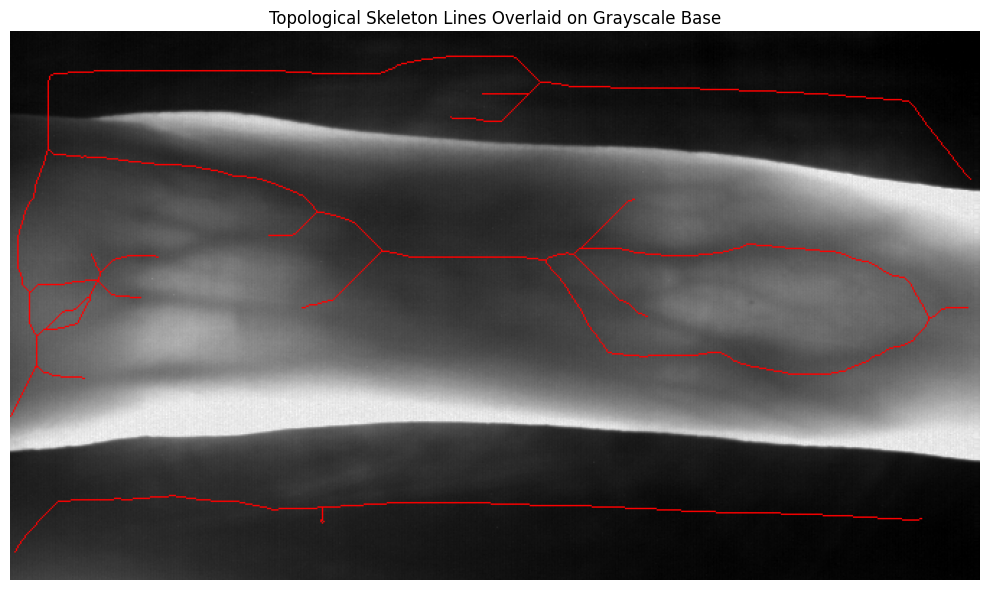

In [9]:
# Convert baseline frame maps to color space layout to track visualization
img_overlay = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
img_overlay[skeleton] = [0, 0, 255]  # Inject Red tracking channels across coordinate points

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
plt.title('Topological Skeleton Lines Overlaid on Grayscale Base')
plt.axis('off')
plt.tight_layout()
plt.show()

# Cell 10 — Test consistency across multiple subjects (UTFVP Batches)

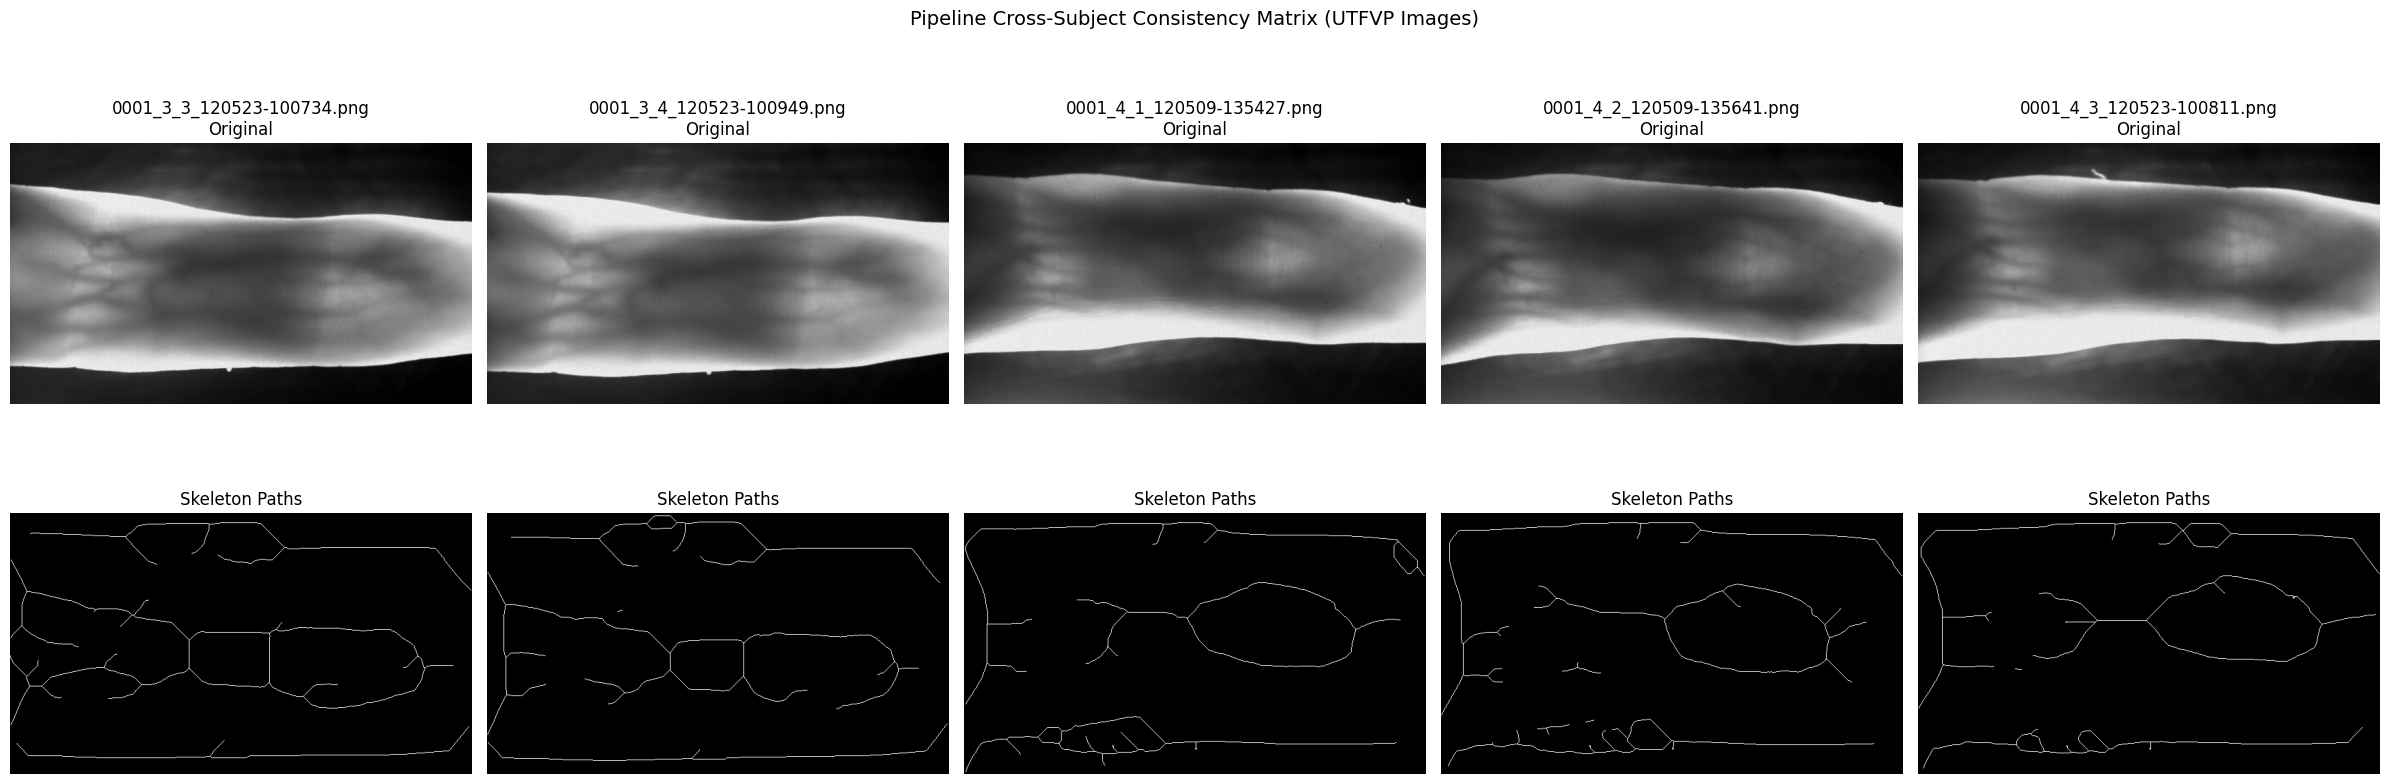

In [10]:
def full_pipeline(img_path, clip_limit=5.0, num_iter=20, kappa=30.0, gamma=0.15, option=1):
    """
    Consolidated preprocessing and structural topological thinning sequence.
    """
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 1. Contrast Alignment
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(5, 5))
    enhanced = clahe.apply(gray)
    
    # 2. Anisotropic Diffusion 
    smoothed = anisotropic_diffusion(enhanced, num_iter=num_iter, kappa=kappa, gamma=gamma, option=option)
    
    # 3. Structural Isolation
    _, binary = cv2.threshold(smoothed, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # 4. Topological Thinning
    skeleton = skeletonize(binary > 0)
    return gray, skeleton

# Grab 5 distinct file points directly out of the sorted file array lists
test_images = all_images[10:15]

fig, axes = plt.subplots(2, 5, figsize=(24, 9))
processed_results = []

for i, path in enumerate(test_images):
    gray, skel = full_pipeline(path)
    skel_uint8 = (skel * 255).astype(np.uint8)
    label = path.name  # Target standard image name strings
    
    processed_results.append((gray, skel, label))

    axes[0, i].imshow(gray)
    axes[0, i].set_title(f'{label}\nOriginal')
    axes[0, i].axis('off')

    axes[1, i].imshow(skel_uint8)
    axes[1, i].set_title(f'Skeleton Paths')
    axes[1, i].axis('off')

plt.suptitle('Pipeline Cross-Subject Consistency Matrix (UTFVP Images)', fontsize=14)
plt.tight_layout()
plt.show()

# Cell 11 — Final parameter decision tracking

In [11]:
# Updated tracking mapping parameters tailored to the UTFVP dataset signature configurations
FINAL_PARAMS = {
    'clahe_clip_limit': 5.0,
    'clahe_tile_grid': (5, 5),
    'diffusion_num_iter': 20,
    'diffusion_kappa': 30.0,
    'diffusion_gamma': 0.15,
    'diffusion_option': 1,
    'binarization': 'otsu_inv',
    'dataset': 'UTFVP_Twente_Database'
}

print('Configured Parameters for Module Integration Hand-Off:')
for k, v in FINAL_PARAMS.items():
    print(f'  {k}: {v}')

Configured Parameters for Module Integration Hand-Off:
  clahe_clip_limit: 5.0
  clahe_tile_grid: (5, 5)
  diffusion_num_iter: 20
  diffusion_kappa: 30.0
  diffusion_gamma: 0.15
  diffusion_option: 1
  binarization: otsu_inv
  dataset: UTFVP_Twente_Database
